# **Google Play Store App Analytics**



# **Project Summary -**

#### **1. Introduction and Objective**

The Google Play Store is a rapidly evolving and competitive digital marketplace, where app developers constantly strive to maintain performance, relevance, and user satisfaction. This project aims to conduct a comprehensive analysis of Play Store app data and user reviews to uncover key trends, identify growth opportunities, and generate actionable insights. The ultimate objective is to empower developers with data-driven strategies for optimizing app quality, improving user experience, and enhancing market performance.

#### **2. Dataset Overview**

The analysis is based on two publicly available datasets:

* **App Dataset**: Includes 10,358 entries with information such as app name, category, rating, number of reviews, size, installs, type (free or paid), price, and last update date.
* **User Review Dataset**: Comprises 29,644 translated user reviews, each labeled with sentiment (Positive, Neutral, Negative), along with polarity and subjectivity scores.

#### **3. Data Cleaning and Preprocessing**

To ensure high data quality and meaningful analysis, extensive preprocessing was performed:

* **Type Conversion**: Columns such as `Reviews`, `Installs`, `Size`, `Price`, and `Last Updated` were converted into appropriate numeric or datetime formats.
* **Missing Values**:

  * In the app dataset, missing values were filled using the **median** (for numerical columns like `Size` and `Rating`) and **mode** (for categorical columns like `Type` and `Android Ver`). Missing entries in `Current Ver` were filled with a placeholder like "Unknown."
  * In the review dataset, rows with missing `Translated_Review` values were removed.
* **Normalization**: Non-numeric characters (e.g., “+”, “M”, “\$”) were removed from numerical fields to enable analysis.
* **Formatting**: The `Android Ver` column was cleaned to ensure consistency in formatting for compatibility analysis.

#### **4. Exploratory Data Analysis (EDA)**

The EDA uncovered several important trends:

* **Ratings**: The majority of apps have ratings above 4.0, indicating strong user satisfaction. Apps below 3.5 suggest areas needing improvement.
* **Category Trends**: Categories such as "FAMILY", "GAME", and "TOOLS" dominate the app store. Niche segments like "BEAUTY" and "COMICS" show potential for market expansion.
* **Free vs. Paid Apps**: Free apps constitute 92.6% of the total. Although fewer in number, paid apps tend to receive slightly higher average ratings, indicating better perceived value.
* **Review Distribution**: A small number of apps garner the vast majority of reviews, reflecting strong brand recognition and user engagement.

#### **5. Sentiment Analysis**

User reviews were analyzed for sentiment to gauge user perceptions:

* **Sentiment Distribution**: 58% of reviews are positive, 26% neutral, and 16% negative, suggesting overall satisfaction with available apps.
* **Polarity & Subjectivity**: Sentiment polarity trends positive, while a mix of subjective and objective reviews provides developers with both emotional and actionable insights.

#### **6. Key Insights**

* Apps sized between **10–50MB** with ratings above 4.0 are more likely to be highly downloaded and positively reviewed.
* Categories like **"GAME"** and **"COMMUNICATION"** show high engagement and revenue potential.
* Underrepresented segments like **"BEAUTY"** offer opportunities for differentiation and niche targeting.
* **Paid apps**, though less common, demonstrate greater user satisfaction compared to free apps.

#### **7. Business Implications**

Based on the findings, the following strategies are recommended for developers:

* **Improve Low-Rated Apps**: Focus on enhancing functionality and user experience for apps with ratings below 4.0.
* **Invest Strategically**: Prioritize high-growth categories such as "GAME" and "FAMILY," while also tapping into underserved niches.
* **Adopt a Freemium Model**: Offer core functionality for free, with optional in-app purchases or upgrades to increase both reach and revenue.
* **Foster User Engagement**: Encourage reviews and respond to feedback, especially negative ones, to build a strong public image and improve app ratings.

#### **8. Conclusion**

This project delivers valuable insights into app performance, user preferences, and market opportunities within the Google Play Store. Through rigorous data analysis and sentiment evaluation, developers are equipped with practical recommendations to enhance app quality, align with user expectations, and capitalize on emerging market trends. The study lays a solid foundation for continuous improvement, strategic planning, and data-driven innovation in the mobile app ecosystem.



# **GitHub Link -**

https://github.com/ruchinailwal

# **Problem Statement**


In a highly competitive Play Store environment, many apps struggle to achieve high downloads, positive ratings, and user satisfaction. Despite the availability of rich app and review data, developers often lack clear insights into the factors driving app success.
This project aims to explore and analyze Play Store app features and customer reviews to identify the key drivers of user engagement and app performance, helping developers make informed, data-driven decisions.

#### **Define Your Business Objective?**

The objective of this project is to explore and analyze Play Store app data and user reviews to identify key factors that drive app success and user engagement. By examining app features like category, size, price, and user sentiments, the project aims to uncover actionable insights that can help developers improve app quality, enhance user satisfaction, and achieve better market performance.



### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
df1=pd.read_csv("Play Store Data.csv")  #load Play Store data
df2=pd.read_csv("User Reviews.csv")     #load User Reviews data

#   **Play Store Data**

## ***1. Know Your Data***

### handling duplicates

In [3]:
# Drop exact duplicates
df1.drop_duplicates(inplace=True)
#Reset index for neatness
df1.reset_index(drop=True, inplace=True)

### Dataset First View

In [4]:
# Dataset First Look
df1

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10353,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10354,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10355,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10356,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
df1.shape

(10358, 13)

### Dataset Information

In [6]:
# Dataset Info
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10358 entries, 0 to 10357
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          8893 non-null   float64
 3   Reviews         10358 non-null  object 
 4   Size            10358 non-null  object 
 5   Installs        10358 non-null  object 
 6   Type            10357 non-null  object 
 7   Price           10358 non-null  object 
 8   Content Rating  10357 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10350 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.0+ MB


### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df1.duplicated().sum()

np.int64(0)

### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df1.isnull().sum()

,0
App,0
Category,0
Rating,1465
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


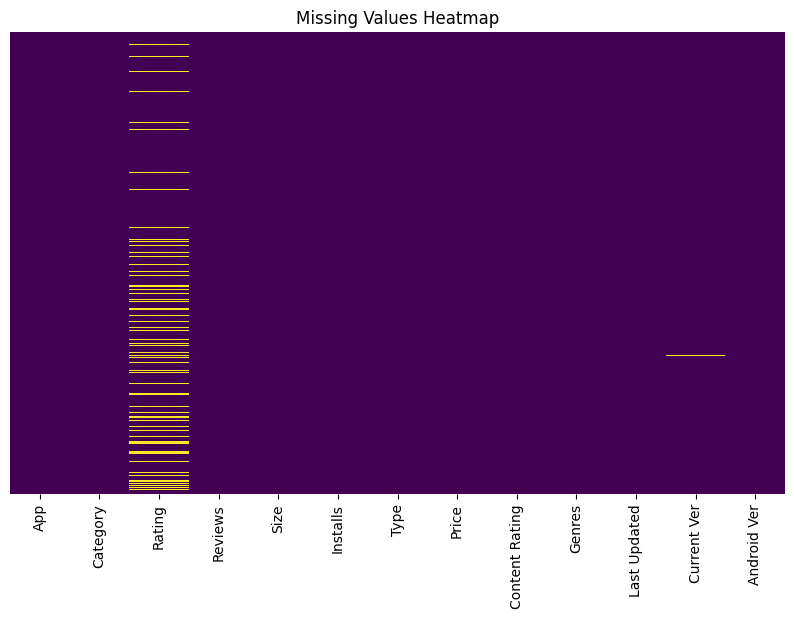

In [9]:
# Visualizing the missing values

missing_data = df1.isnull() # create a dataframe of missing values
plt.figure(figsize=(10, 6)) # set figure size
sns.heatmap(missing_data, cbar=False, cmap="viridis", yticklabels=False) #plot the heatmap
plt.title("Missing Values Heatmap") #add title
plt.show()

### What did you know about your dataset?

The Playstore dataset consists of 10,358 rows and 13 columns, with the following key details:

1. **Data Types:**

* 1 column contains numerical data of type float64 (e.g., Ratings).
* 12 columns are of type object, representing categorical or textual information.

2. **Duplicate Rows:**

* Duplicate entries have already been addressed, ensuring no duplicates remain in the dataset.

3. **Missing Values:**

Missing data is present in the following columns:
* Ratings: 1,465 missing values.
* Type: 1 missing value.
* Content Rating: 1 missing value.
* Current Ver: 8 missing values.
* Android Ver: 3 missing values.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df1.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [11]:
# Dataset Describe
df1.describe()

,Rating
count,8893.000000
mean,4.189542
std,0.545452
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


### Variables Description

1. **`App`**: The name of the application (e.g., Instagram, Facebook), used to uniquely identify each app.
2. **`Category`**: The category to which the app belongs (e.g., Education, Game, Lifestyle), representing its primary functionality.
3. **`Rating`**: The average user rating for the app, ranging from 1 (lowest) to 5 (highest), indicating user satisfaction.
4. **`Reviews`**: The total number of user reviews for the app, reflecting user engagement.
5. **`Size`**: The size of the app (in MB or KB), showing its storage requirement.
6. **`Installs`**: The number of times the app has been downloaded, indicating its popularity.
7. **`Type`**: Indicates whether the app is **Free** or **Paid**, representing its pricing model.
8. **`Price`**: The cost of the app (in USD), where 0 indicates free apps.
9. **`Content Rating`**: The recommended age group for the app (e.g., Everyone, Teen, Mature), showing its suitability for different audiences.
10. **`Genres`**: The detailed genre(s) of the app (e.g., Puzzle, Action, Social), providing additional categorization.
11. **`Last Updated`**: The date when the app was last updated, reflecting developer activity and app maintenance.
12. **`Current Ver`**: The current version of the app, showing its latest iteration.
13. **`Android Ver`**: The minimum Android version required to run the app, ensuring device compatibility.


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
df1.nunique()

,0
App,9660
Category,34
Rating,40
Reviews,6002
Size,462
Installs,22
Type,3
Price,93
Content Rating,6
Genres,120


In [13]:
# Check Unique Values for each variable.
columns_to_check = ['App','Category','Rating','Reviews','Size','Installs','Type','Price','Content Rating','Genres','Last Updated','Current Ver','Android Ver']

for col in columns_to_check:
    print(f"\nUnique values in '{col}':")
    print(df1[col].unique())



Unique values in 'App':
['Photo Editor & Candy Camera & Grid & ScrapBook' 'Coloring book moana'
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps' ...
 'Parkinson Exercices FR' 'The SCP Foundation DB fr nn5n'
 'iHoroscope - 2018 Daily Horoscope & Astrology']

Unique values in 'Category':
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

Unique values in 'Rating':
[ 4.1  3.9  4.7  4.5  4.3  4.4  3.8  4.2  4.6  3.2  4.   nan  4.8  4.9
  3.6  3.7  3.3  3.4  3.5  3.1  5.   2.6  3.   1.9  2.5  2.8  2.7  1.
  2.9  2.3  2.2  1.7  2.   1.8  2.4  1.6  2.1  1.4  1.5  1.2 19. ]

## 3. ***Data Wrangling***

### Data Wrangling Code

###convert data type

In [14]:
# fetch data type of each column in df1
df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [15]:
#Convert Reviews column to integer datatype

def clean_reviews(val):
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    elif val.isdigit():
        return int(val)
    else:
        return np.nan

df1['Reviews'] = df1['Reviews'].apply(clean_reviews).astype('Int64')

In [16]:
#check data type of Reviews column
df1['Reviews'].dtype

Int64Dtype()

In [17]:
# Clean Installs column and convert to integer

# Remove '+' and ',' characters
df1['Installs'] = df1['Installs'].str.replace('[+,]', '', regex=True)

# Remove any extra spaces
df1['Installs'] = df1['Installs'].str.strip()

# Convert to numeric (invalid entries become NaN)
df1['Installs'] = pd.to_numeric(df1['Installs'], errors='coerce')

# Drop rows with NaN in 'Installs' (caused by invalid entries)
df1 = df1.dropna(subset=['Installs']).reset_index(drop=True)

# Convert to integer
df1['Installs'] = df1['Installs'].astype(int)

In [18]:
# Check data type of Installs column
print(df1['Installs'].dtype)  # Should be int64

int64


In [19]:
# Convert Last Updated to datetime
df1['Last Updated'] = pd.to_datetime(df1['Last Updated'])

In [20]:
# Check data type of Last Updated column
df1['Last Updated'].dtype

dtype('<M8[ns]')

In [21]:
# Clean Price: remove '$' and convert to float
df1['Price'] = df1['Price'].str.replace('$', '').astype(float)

In [22]:
# Check data type of Price column
df1['Price'].dtype

dtype('float64')

In [23]:
# Clean Size and convert to float
def size_to_mb(size):
    if size == 'Varies with device':
        return np.nan
    elif 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024  # convert kB to MB
    else:
        return np.nan

df1['Size'] = df1['Size'].apply(size_to_mb)

In [24]:
# Check data type of Size column
df1['Size'].dtype

dtype('float64')

In [25]:
# Clean Android Version
df1['Android Ver'] = df1['Android Ver'].replace('Varies with device', np.nan)

In [26]:
# Check data type of Android Ver column
df1['Android Ver'].dtype

dtype('O')

In [27]:
df1

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10352,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up
10353,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up
10354,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up
10355,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,NaN


###handling missing values

In [28]:
#check data type of each column in df1
df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,Int64
Size,float64
Installs,int64
Type,object
Price,float64
Content Rating,object
Genres,object


In [29]:
#print all columns in df1
df1.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [30]:
#num cols
#print all numerical columns
num_cols=df1.select_dtypes(include=['int64','float64'])
num_cols

,Rating,Reviews,Size,Installs,Price
0,4.1,159,19.0,10000,0.0
1,3.9,967,14.0,500000,0.0
2,4.7,87510,8.7,5000000,0.0
3,4.5,215644,25.0,50000000,0.0
4,4.3,967,2.8,100000,0.0
...,...,...,...,...,...
10352,4.5,38,53.0,5000,0.0
10353,5.0,4,3.6,100,0.0
10354,NaN,3,9.5,1000,0.0
10355,4.5,114,NaN,1000,0.0


In [31]:
# cat cols
# print all categorical columns
cat_cols=df1.select_dtypes(include=['object'])
cat_cols

,App,Category,Type,Content Rating,Genres,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,Free,Everyone,Art & Design,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,Free,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,Free,Everyone,Art & Design,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,Free,Teen,Art & Design,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,Free,Everyone,Art & Design;Creativity,1.1,4.4 and up
...,...,...,...,...,...,...,...
10352,Sya9a Maroc - FR,FAMILY,Free,Everyone,Education,1.48,4.1 and up
10353,Fr. Mike Schmitz Audio Teachings,FAMILY,Free,Everyone,Education,1.0,4.1 and up
10354,Parkinson Exercices FR,MEDICAL,Free,Everyone,Medical,1.0,2.2 and up
10355,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,Free,Mature 17+,Books & Reference,Varies with device,NaN


In [32]:
#check missing values
df1.isnull().sum()

,0
App,0
Category,0
Rating,1465
Reviews,0
Size,1526
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


#####handle missing values of Rating column

In [33]:
#find skew
df1['Rating'].skew() #it is negatively skewed

np.float64(-1.8235171151017526)

In [34]:
# find median
df1['Rating'].median()

4.3

In [35]:
#Replace missing values with median
df1['Rating']=df1['Rating'].fillna(4.3)

#####handle missing values of Size column

In [36]:
#find skew
df1['Size'].skew()

np.float64(1.569785090297752)

In [37]:
#find median
df1['Size'].median()

13.0

In [38]:
# fill missing values with median
df1['Size']=df1['Size'].fillna(13.0)

####handling missing values of Type column

In [39]:
#find the mode
df1['Type'].mode()

,Type
0,Free


In [40]:
# fill missing values with mode value
df1['Type']=df1['Type'].fillna('Free')

#### handle missing values of Current Ver

In [41]:
#filling missing values of Current Ver column with placeholder value 'Unknown'
df1['Current Ver'] = df1['Current Ver'].fillna('Unknown')

####handling missing values of Android Version

In [42]:
#find mode
df1['Android Ver'].mode()

,Android Ver
0,4.1 and up


In [43]:
# fill missing values with mode value
df1['Android Ver']=df1['Android Ver'].fillna('4.1 and up')

In [44]:
#Final check: ensure no missing values remain
print("Remaining Missing Values:")
print(df1.isnull().sum())

Remaining Missing Values:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


### What all manipulations have you done and insights you found?

#### **Data Manipulations and Insights**
In this project, we carried out several data cleaning and manipulation tasks to prepare the Play Store dataset for analysis. The main steps and insights are summarized below:

1. **Data Type Conversion and Column Cleaning**

To ensure proper analysis, columns with incorrect data types were converted, and necessary cleaning steps were performed:

* Reviews: Converted from object to integer.
* Installs: Converted from object to integer by removing non-numeric characters (like commas and plus signs).
* Last Updated: Converted from object to datetime for time-series analysis.
* Price: Converted from object to float by removing currency symbols.
* Size: Cleaned and converted from object to float, replacing non-numeric characters (e.g., 'M', 'K').
* Android Ver: Cleaned to ensure consistent formatting of Android versions.

2. **Handling Missing Values**

To address missing values in the dataset, various imputation strategies were applied:

* Rating: Missing values were replaced with the median, preserving the overall data distribution.
* Size: Missing values were also replaced with the median to maintain consistency.
* Type: Missing values were filled with the mode, representing the most frequently occurring category.
* Current Ver: Missing values were replaced with the placeholder value 'Unknown' for clarity.
* Android Ver: Missing values were filled with the mode to ensure uniformity.

3. **Insights Gained**
* Proper data type conversions ensured accurate numerical analysis for columns like Reviews, Installs, and Price.
* Cleaning and imputing missing values provided a complete and structured dataset, ready for further exploratory data analysis.
* Addressing inconsistencies in columns like Android Ver and Size helped in creating standardized data, leading to more reliable insights.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

## **Univariate**

1. **What is the distribution of app ratings?**

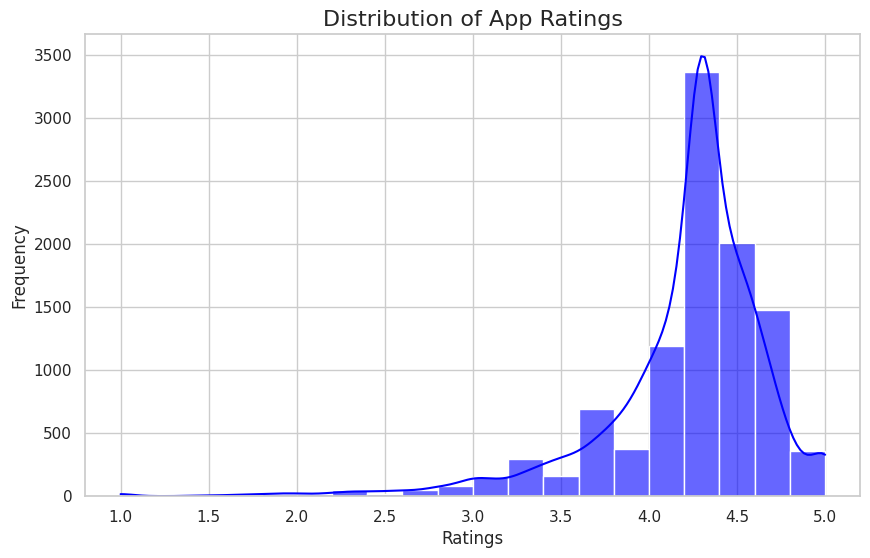

In [45]:
# Chart - 1 visualization code
# Histogram

#Set the plot style
sns.set(style="whitegrid")

#Plot the Histogram and KDE for app ratings
plt.figure(figsize=(10, 6))
sns.histplot(df1['Rating'], kde=True, bins=20, color='blue', alpha=0.6)

#Add labels and title
plt.title('Distribution of App Ratings', fontsize=16)
plt.xlabel('Ratings', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show() #show the plot

##### 1. Why did you pick the specific chart?

I selected the Histogram with KDE (Kernel Density Estimate) plot because it provides both a visual summary of the frequency distribution of app ratings and a smooth curve to observe the underlying distribution shape. This combination allows us to easily identify common rating values, overall spread, skewness, and the presence of any outliers or patterns in the ratings.

##### 2. What is/are the insight(s) found from the chart?

* The majority of apps have high ratings between 4.0 and 4.5, indicating generally good user satisfaction.
* There is a positive skew, meaning fewer apps have lower ratings.
* A sharp peak near 4.3–4.4 suggests that many apps cluster around this rating.
* Very few apps have ratings below 3.0, which shows that poorly rated apps are less common on the Play Store.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes, these insights can help in the following ways:
* For developers and businesses, understanding that users tend to download and positively rate apps that maintain a 4.0+ rating can be crucial. It can motivate efforts toward improving app quality, bug fixing, and user experience to stay competitive.
* Marketing teams can focus on promoting apps that cross the 4.0 threshold to increase credibility and downloads.
* Product managers can benchmark average ratings (around 4.3) as a target for new or underperforming apps.

(ii) Negative Insight:
* Apps with ratings below 3.0 are rare and likely to perform poorly. If a business's app consistently falls in this range, it can signal a need for major improvements or risk losing user trust and visibility in the Play Store.

2. **Which app category has the highest number of apps?**

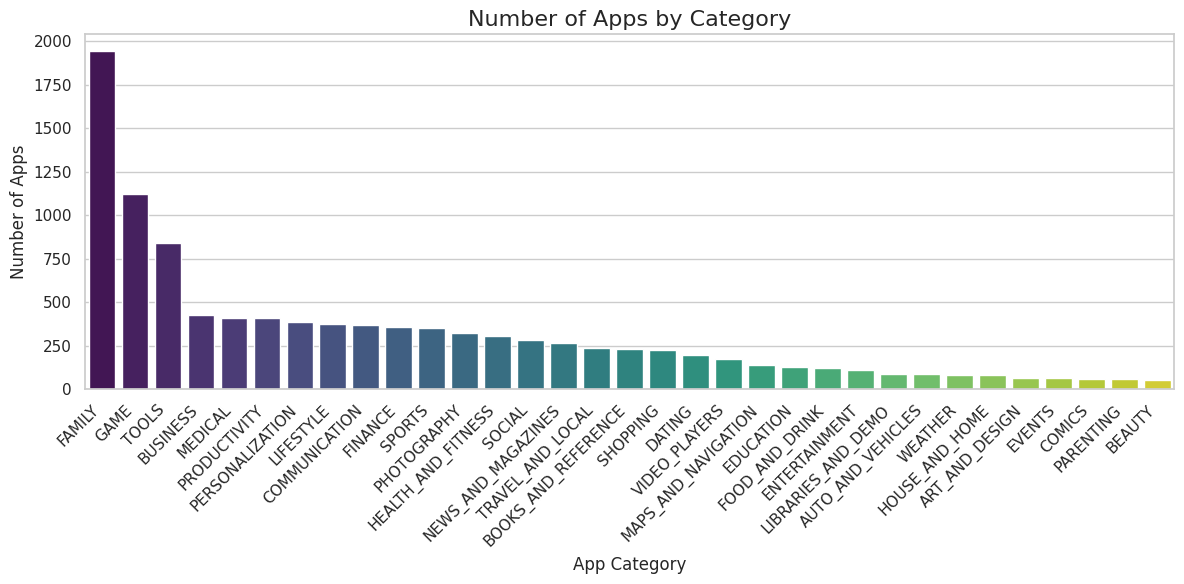

In [46]:
# Chart - 2 visualization code
#Bar Chart

#Count the number of apps in each category
category_counts = df1['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

#Set the plot size and style
plt.figure(figsize=(12, 6))
sns.barplot(data=category_counts, x='Category', y='Count', hue='Category', palette='viridis', legend=False) #plot the bar chart

#Add labels and title
plt.title('Number of Apps by Category', fontsize=16)
plt.xlabel('App Category', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability

#Show the plot
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing discrete categories—in this case, different app categories. It clearly visualizes which categories have the most or fewest apps, making it easy to interpret and compare the distribution across all categories.



##### 2. What is/are the insight(s) found from the chart?

The "FAMILY" category has the highest number of apps, followed by "GAME" and "TOOLS". This suggests that developers focus heavily on family-oriented and entertainment-based applications. On the other end, categories like "BEAUTY", "COMICS", and "PARENTING" have very few apps, indicating limited competition or niche markets.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes, these insights can drive positive business impact. Businesses or developers looking to enter the app market can:
* Capitalize on high-demand categories like FAMILY or GAME where user interest is strong.
* Alternatively, they can target underrepresented categories (e.g., BEAUTY or COMICS) to fill gaps in the market with innovative or high-quality apps, facing less competition.

(ii) A negative growth risk might exist in oversaturated categories like FAMILY, where standing out becomes harder. New apps in crowded categories may struggle with visibility unless they offer a unique value proposition or significant marketing push.



3. **What is the proportion of free vs paid apps?**

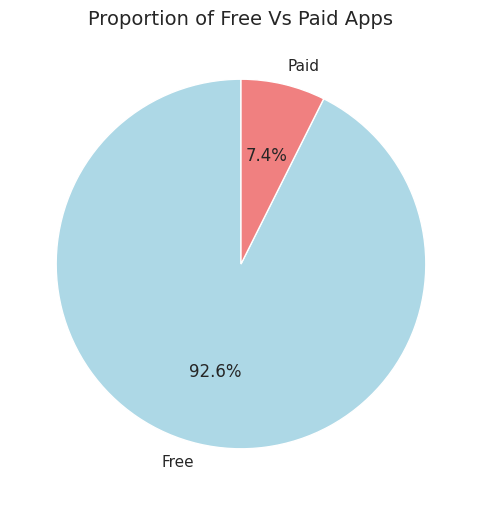

In [47]:
# Chart - 3 visualization code
#Pie Chart

app_type= df1['Type'].value_counts().reset_index()

#Set the plot size and style
plt.figure(figsize=(6,6))
plt.pie(app_type['count'],labels=df1['Type'].unique(),autopct='%0.1f%%',startangle=90,colors=['lightblue','lightcoral']) # create pie chart

#Add title
plt.title('Proportion of Free Vs Paid Apps', fontsize=14)

#Show the plot
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is ideal for visualizing categorical proportions. It clearly conveys the share of free vs. paid apps, making it easy to compare their distribution.

##### 2. What is/are the insight(s) found from the chart?

Approximately 92.6% of the apps are free, while only 7.4% are paid. This highlights a strong preference for free apps on the Play Store.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insight suggests that adopting a freemium or ad-supported model may align better with user expectations and market trends. However, the low share of paid apps also signals challenges in monetizing through upfront purchases alone.



4. **What is the distribution of the number of reviews?(using boxplot)**

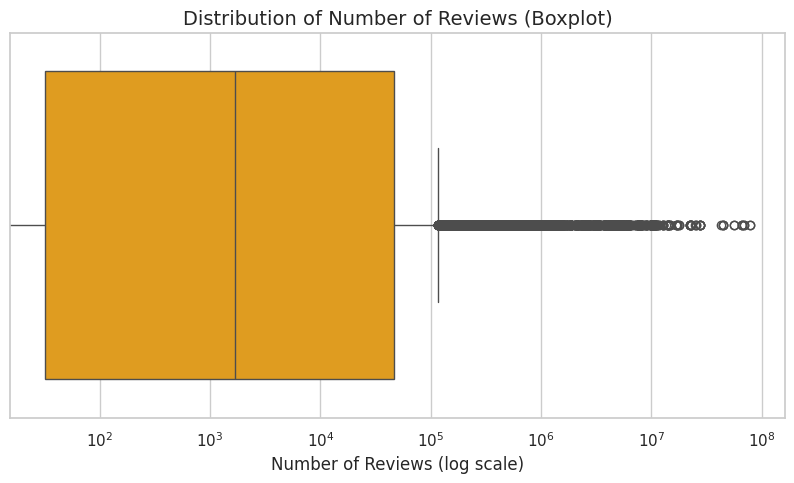

In [48]:
# Chart - 4 visualization code
#Boxplot

import matplotlib.ticker as mtick

#Set the plot size and style
plt.figure(figsize=(10, 5))
sns.boxplot(data=df1, x='Reviews', color='orange') #create boxplot

#Add title and label
plt.xscale('log') # Use log scale for better visibility
plt.xlabel('Number of Reviews (log scale)', fontsize=12)
plt.title('Distribution of Number of Reviews (Boxplot)', fontsize=14)

#Show the plot
plt.show()


##### 1. Why did you pick the specific chart?

The boxplot was chosen to clearly show the distribution and spread of review counts, including outliers. The log scale was applied to better visualize the wide range of values across apps.

##### 2. What is/are the insight(s) found from the chart?

Most apps receive relatively few reviews, while a small number get extremely high reviews. The data is right-skewed with many outliers, indicating a concentration of user engagement in a few popular apps.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights highlight the need to improve visibility and engagement for low-performing apps. Identifying top-performing apps can guide strategies to boost user interaction. Apps with few reviews may risk limited growth without targeted improvement.

5. **What is the distribution of the number of reviews?(using histogram)**

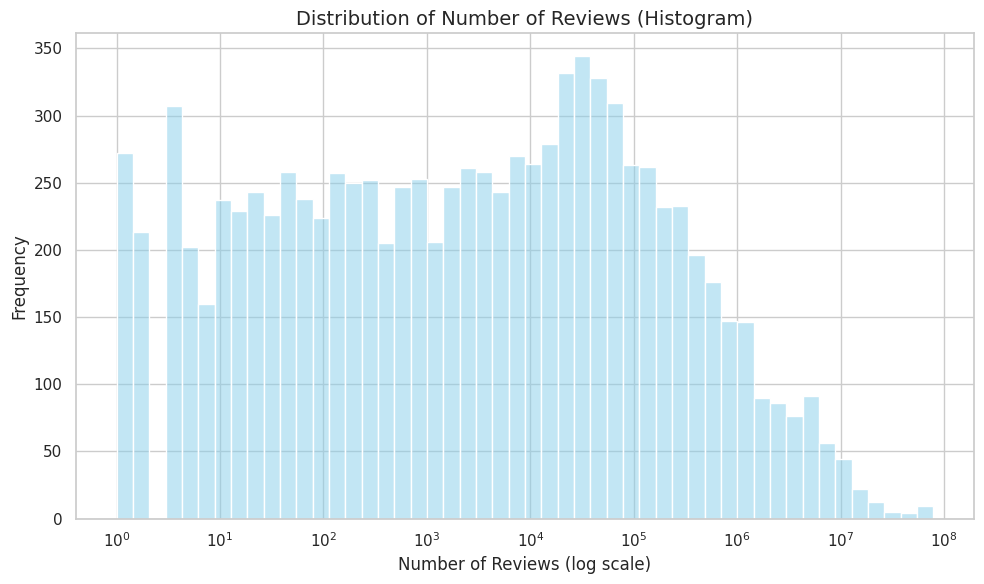

In [49]:
# Chart - 5 visualization code
#Histogram

#Set figure size
plt.figure(figsize=(10, 6))

#Plot Histogram
#Use log scale to handle wide range of values
sns.histplot(data=df1, x='Reviews', bins=50, kde=True, color='skyblue', log_scale=(True, False)) # plot Histogram

#Add labels and title
plt.xlabel('Number of Reviews (log scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Number of Reviews (Histogram)', fontsize=14)

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose the histogram because it effectively illustrates the distribution of app reviews across different review count ranges. It highlights how many apps fall into each range, making it ideal for understanding overall user engagement patterns.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that most apps have a relatively low number of reviews, while a few apps have very high review counts. This indicates a positively skewed distribution, where a small number of apps dominate user attention.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can guide developers and marketers to analyze what makes top-reviewed apps successful and replicate those strategies. However, the heavy skew also indicates that many apps struggle to gain visibility, which could lead to negative growth if not addressed with targeted marketing and quality improvements.


6. **How is the size of apps distributed?**

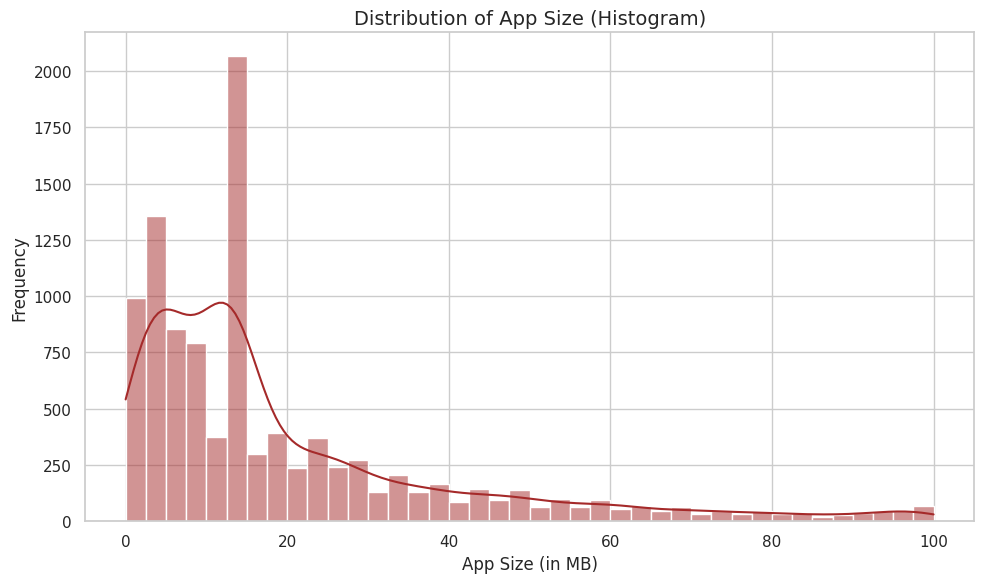

In [50]:
# Chart - 6 visualization code
#Histogram

#Set figure size
plt.figure(figsize=(10,6))

#Plot histogram
sns.histplot(data=df1,x='Size',bins=40,kde=True,color='brown')

#Add labels and title
plt.xlabel('App Size (in MB)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of App Size (Histogram)', fontsize=14)

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a histogram because it effectively visualizes the distribution of app sizes across the dataset, helping to understand how frequently different size ranges occur.



##### 2. What is/are the insight(s) found from the chart?

The majority of apps are relatively small in size, with a large number under 20 MB. The distribution is right-skewed, indicating a smaller proportion of large-sized apps.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes, these insights guide developers to optimize app sizes. Since users tend to prefer lightweight apps, especially in regions with limited storage or slower networks, targeting a smaller app footprint can improve download rates and user retention.

(ii) Yes, apps with very large sizes might face lower install rates due to data and storage limitations, leading to potential negative growth if not optimized.

            

7. **Which are the top 10 most installed apps?**

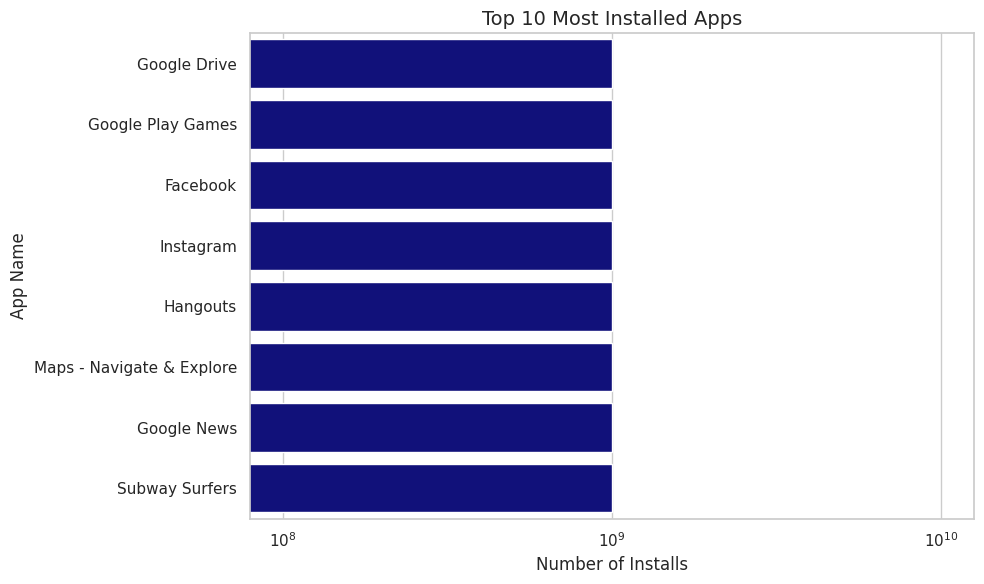

In [51]:
# Chart - 7 visualization code
#Bar Chart

#Sort by number of installs and take top 10 apps
top_installed = df1.sort_values(by='Installs', ascending=False).head(10)

#Plot the top 10 most installed apps
#Plot barchart
plt.figure(figsize=(10, 6))
sns.barplot(x='Installs', y='App', data=top_installed,color='darkblue')

#Add labels and title
plt.xlabel('Number of Installs', fontsize=12)
plt.ylabel('App Name', fontsize=12)
plt.title('Top 10 Most Installed Apps', fontsize=14)

#Use log scale as numbers are too large
plt.xscale('log')

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to visually highlight the most installed apps, giving a clear comparison of app popularity based on install counts. A horizontal barplot with log scale is ideal for comparing large values across categories (apps).

##### 2. What is/are the insight(s) found from the chart?

* All top 10 apps have over 1 billion installs, indicating their massive popularity.
* Google apps dominate the list, showing strong user reliance on core Google services.
* Social media and gaming apps (e.g., Facebook, Instagram, Subway Surfers) are also highly popular, indicating user preference for communication and entertainment.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes, they highlight which app categories (e.g., communication, social media) are most popular, helping businesses focus on high-demand areas and replicate successful app traits like strong branding and ecosystem integration.

(ii) Yes. The market is saturated with dominant apps from major brands, making it difficult for new or small developers to compete, which may hinder growth without a unique value proposition.

8. **What are the trends in app updates over the years?**

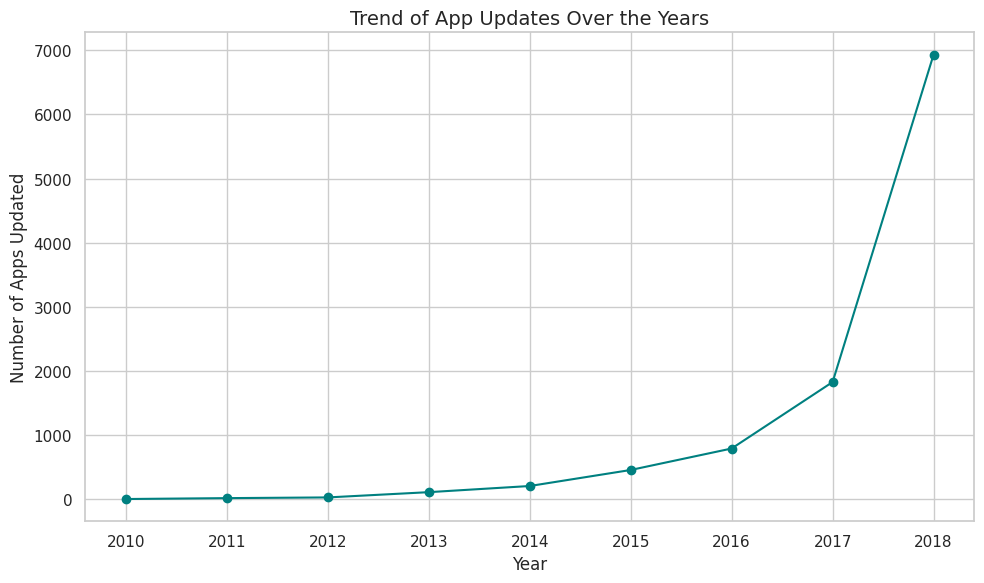

In [52]:
# Chart - 8 visualization code
#Line chart

#Extract year from 'Last Updated'
df1['Last Updated Year'] = df1['Last Updated'].dt.year

#Count number of updates per year
updates_per_year = df1['Last Updated Year'].value_counts().sort_index()

#Set the plot size and style
plt.figure(figsize=(10, 6))
plt.plot(updates_per_year.index, updates_per_year.values, marker='o', color='teal') #create line chart

#Add labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Apps Updated', fontsize=12)
plt.title('Trend of App Updates Over the Years', fontsize=14)

#Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I chose a line chart because it is ideal for showing trends over time. It helps clearly visualize how the number of app updates has changed across different years, making it easy to identify patterns and shifts in update frequency.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a sharp increase in the number of app updates over the years, especially from 2016 to 2018. This indicates that developers have become more active in maintaining and improving their apps, possibly due to rising user expectations and competition.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes, the insights highlight the importance of frequent app updates, which can enhance user satisfaction, fix bugs, and add new features—leading to higher retention and better reviews. This encourages developers to adopt consistent update strategies to stay competitive.

(ii) Not directly, but the absence of regular updates may signal app abandonment, leading to negative user perception, reduced installs, and poor ratings—ultimately harming growth. Apps that lag in updates risk losing relevance in a fast-evolving market.










## **Bivariate**

9. **Is there a relationship between app ratings and the number of reviews?**

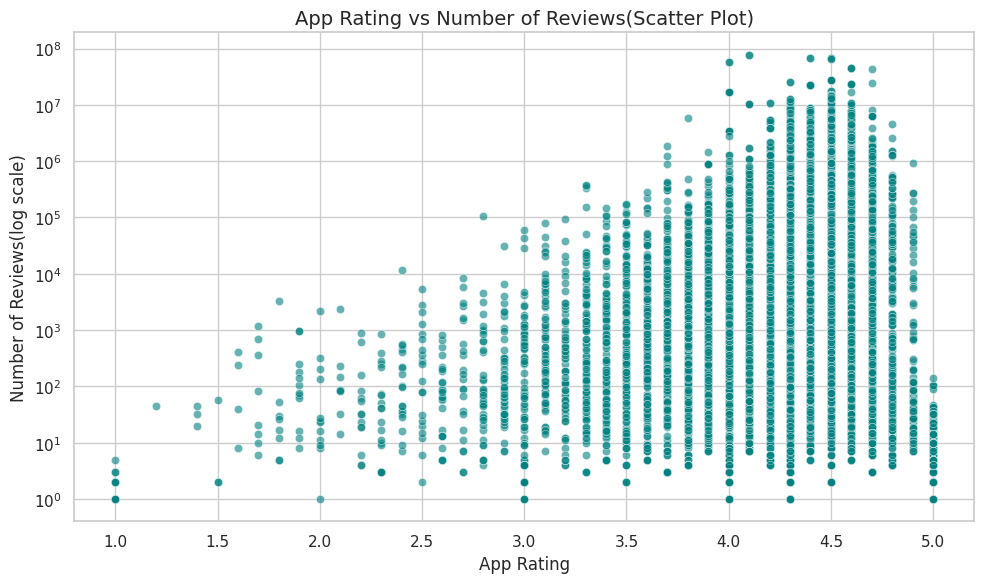

In [53]:
# Chart - 9 visualization code
#Scatter Plot

#Set figure size
plt.figure(figsize=(10,6))

#Plot scatterplot
sns.scatterplot(data=df1, x='Rating',y='Reviews',color='teal',alpha=0.6)

#Use log scale for y-axis to handle skewed review counts
plt.yscale('log')

#Add labels and title
plt.xlabel('App Rating',fontsize=12)
plt.ylabel('Number of Reviews(log scale)',fontsize=12)
plt.title('App Rating vs Number of Reviews(Scatter Plot)',fontsize=14)

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The scatter plot effectively visualizes the relationship between app ratings and the number of reviews. The log scale ensures better interpretation of skewed review counts.

##### 2. What is/are the insight(s) found from the chart?

* Higher-rated apps (4.0–5.0) tend to receive significantly more reviews, indicating strong user engagement.
* Apps with ratings below 3.0 generally have fewer reviews, suggesting low interest or dissatisfaction.
* Some outliers with high reviews but low ratings may indicate controversy or widespread negative feedback.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Impact:** High ratings drive engagement; focus on maintaining ratings above 4.0.
* **Actionable Insight:** Apps with low ratings but high reviews require targeted improvements to prevent reputational damage.


10. **How does the price vary across app categories?**

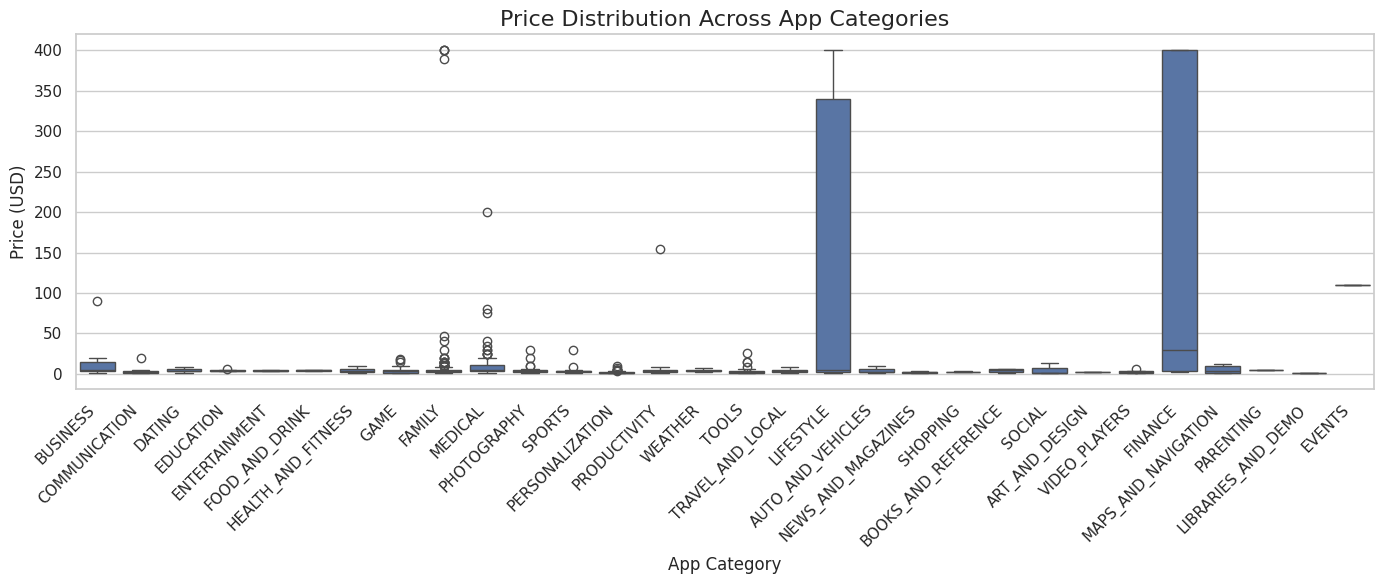

In [54]:
# Chart - 10 visualization code
#Boxplot

#Filter out free apps (price = 0) to focus on variation among paid apps
paid_apps = df1[df1['Price'] > 0]

#Set the plot size and style
plt.figure(figsize=(14, 6))
sns.boxplot(data=paid_apps, x='Category', y='Price') #create boxplot

# Add labels and title
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution Across App Categories', fontsize=16)
plt.xlabel('App Category', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

#Show the plot
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The boxplot is ideal for visualizing the price distribution across different app categories, highlighting variations, outliers, and central tendencies effectively.



##### 2. What is/are the insight(s) found from the chart?

* Most categories have low-priced apps, but significant price outliers exist in "FINANCE" and "MAPS_AND_NAVIGATION" categories.
* Categories like "BUSINESS", "LIFESTYLE", and "MEDICAL" show moderate price ranges.
* Some categories (e.g., "GAME", "EDUCATION") are priced consistently lower with minimal variability.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: Developers in outlier-prone categories like "FINANCE" or "MAPS_AND_NAVIGATION" can explore premium pricing strategies for niche, high-value apps.
* Potential Risks: Overpricing in competitive categories may deter users; developers should ensure that app features justify higher prices.

11. **Are paid apps rated higher than free apps?**

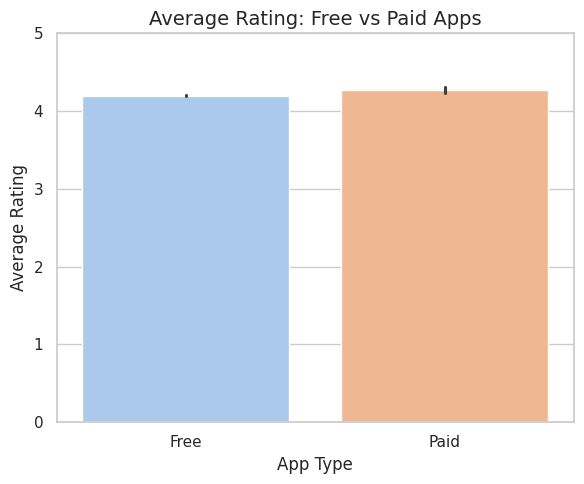

In [55]:
# Chart - 11 visualization code
#Bar Chart

#Set the plot size and style
plt.figure(figsize=(6, 5)) #set figure size
sns.barplot(data=df1, x='Type', y='Rating', hue='Type', palette='pastel', legend=False) #create bar chart

#Add labels and title
plt.title('Average Rating: Free vs Paid Apps', fontsize=14)
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(0, 5)  #Ratings are usually on a scale from 0 to 5

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is appropriate to compare the average ratings of free and paid apps. It simplifies the comparison and highlights any differences in ratings between the two app types.

##### 2. What is/are the insight(s) found from the chart?

* Both free and paid apps have similar average ratings, hovering around 4.0.
* Paid apps show a slightly higher average rating compared to free apps, suggesting that users may value paid apps slightly more.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: Developers can focus on improving free app features to match the perceived quality of paid apps.
* Potential Risks: Paid apps must deliver value for money, as they have only a slight edge in ratings. Failure to meet user expectations could lead to dissatisfaction and fewer purchases.









12. **Is app size related to the number of installs?**

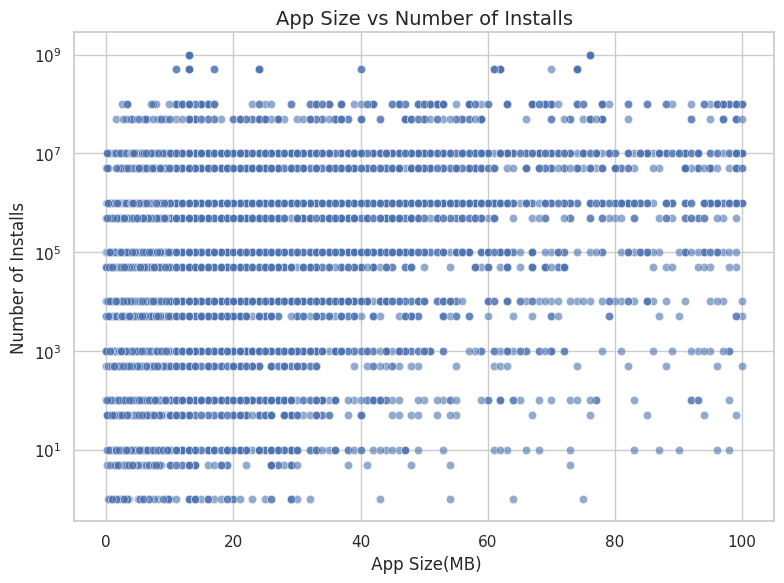

In [56]:
# Chart - 12 visualization code
#Scatter Plot

#Set the plot size and style
plt.figure(figsize=(8,6)) # set figure size
sns.scatterplot(data=df1,x='Size',y='Installs',alpha=0.6) #create scatterplot

#Add labels and title
plt.xlabel(' App Size(MB)',fontsize=12)
plt.ylabel('Number of Installs',fontsize=12)
plt.title('App Size vs Number of Installs',fontsize=14)
plt.yscale('log')

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a scatter plot because it effectively visualizes the relationship between two continuous variables—App Size and Number of Installs—highlighting potential patterns, trends, or clusters in the data.



##### 2. What is/are the insight(s) found from the chart?

The chart shows that apps of all sizes can have high install counts, suggesting no strong correlation between app size and popularity. However, there are more high-install apps in the mid-size range (10–50 MB), indicating that extremely large or small apps may be less likely to be widely downloaded.




##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can guide app developers to optimize app size for broader adoption. Knowing that very large apps might deter users due to storage concerns can inform size reduction strategies. Conversely, assuming that increasing app size will attract more users may lead to negative growth if the app becomes too heavy and less accessible on low-end devices.

13. **How do app installs vary across categories?**

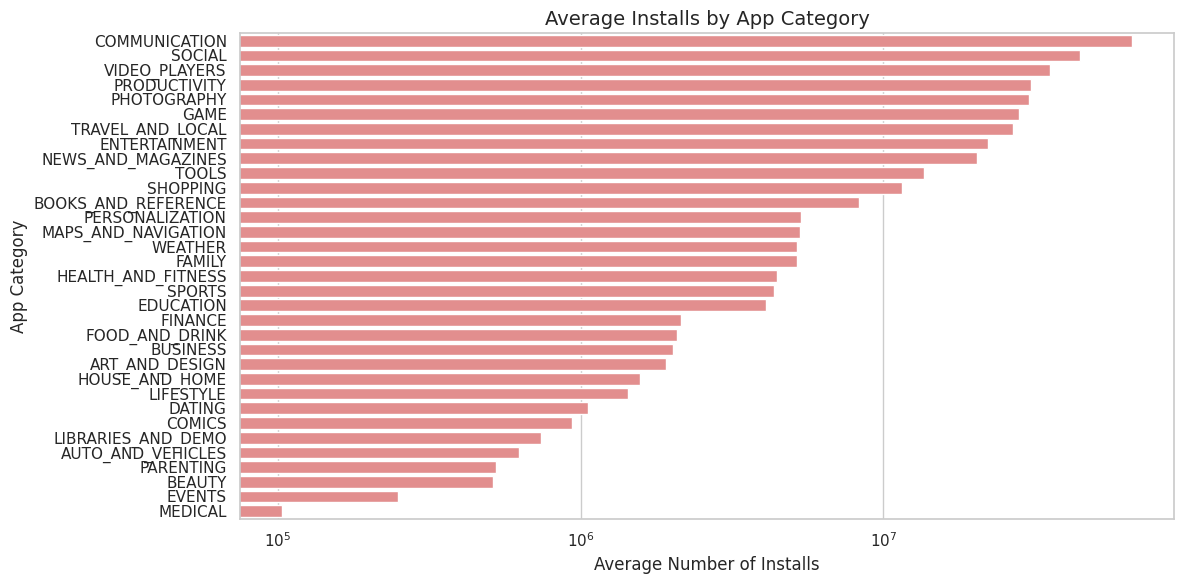

In [57]:
# Chart - 13 visualization code
#Bar chart

#Calculate average installs per category
category_installs = df1.groupby('Category')['Installs'].mean().sort_values(ascending=False)

#Set the plot size and style
plt.figure(figsize=(12, 6))
sns.barplot(x=category_installs.values, y=category_installs.index, color='lightcoral') #create bar chart

#Add labels and title
plt.xlabel('Average Number of Installs', fontsize=12)
plt.ylabel('App Category', fontsize=12)
plt.title('Average Installs by App Category', fontsize=14)

#Use log scale if there's high variance
plt.xscale('log')

#Show the plot
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

This horizontal bar chart was chosen to clearly visualize the average number of installs across app categories. It allows for easy comparison of popularity by app type and handles long category names well.

##### 2. What is/are the insight(s) found from the chart?

* Categories like Communication, Social, and Video Players have the highest average installs, indicating strong user demand.
* In contrast, Medical, Events, and Beauty apps have significantly lower average installs, suggesting niche user bases or limited reach.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can guide strategic app development and marketing. Focusing on high-performing categories can enhance visibility and downloads.
However, categories with low installs might indicate oversaturation or weak demand, which could lead to negative ROI if not addressed with targeted improvements or niche positioning.



## **Multivariate**

14. **Which numeric features in the Play Store dataset are strongly correlated? Can we identify any relationships among Rating, Reviews, Installs, Size, and Price?**

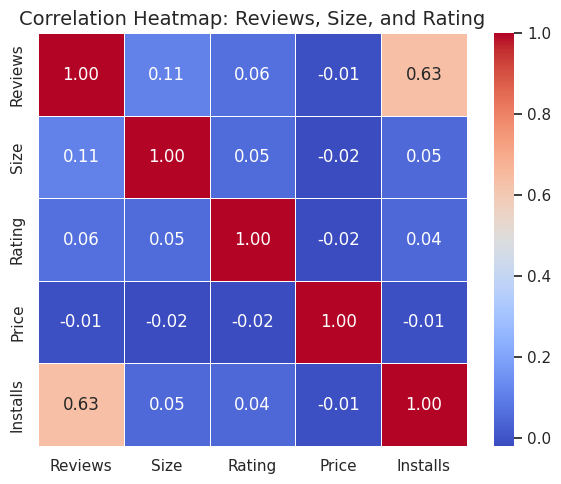

In [58]:
# Chart-14 Correlation Heatmap visualization code

#Select only the required numeric columns
selected_cols = ['Reviews', 'Size', 'Rating','Price','Installs']
corr = df1[selected_cols].corr()

#Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

#Add title
plt.title('Correlation Heatmap: Reviews, Size, and Rating', fontsize=14)

#Show the plot
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The heatmap is ideal for visualizing the correlations between numerical features such as Reviews, Size, Rating, Price, and Installs. It provides a clear and concise way to identify strong or weak relationships among these variables.

##### 2. What is/are the insight(s) found from the chart?

**Strong Correlation:**
* A strong positive correlation (0.63) exists between Reviews and Installs, indicating that apps with higher install counts tend to receive more reviews.

**Weak/No Correlation:**
* Size and Rating show little to no correlation with other variables, suggesting app size and rating operate independently of features like reviews or installs.
* Price is not correlated with Installs, suggesting that higher-priced apps do not necessarily attract more downloads.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
* Apps with more installs attract more reviews, indicating the importance of user engagement strategies to boost downloads.
* Developers should focus on increasing install counts (e.g., through marketing) to generate more user feedback and improve app visibility.

**No Negative Growth:**
* here are no significant negative correlations between key features, meaning no immediate risk factors were identified from the analysis.

15. **Is there any relationship among key numeric features such as Rating, Reviews, Installs, Size, and Price? Can we identify trends, clusters, or correlations from these variables?**

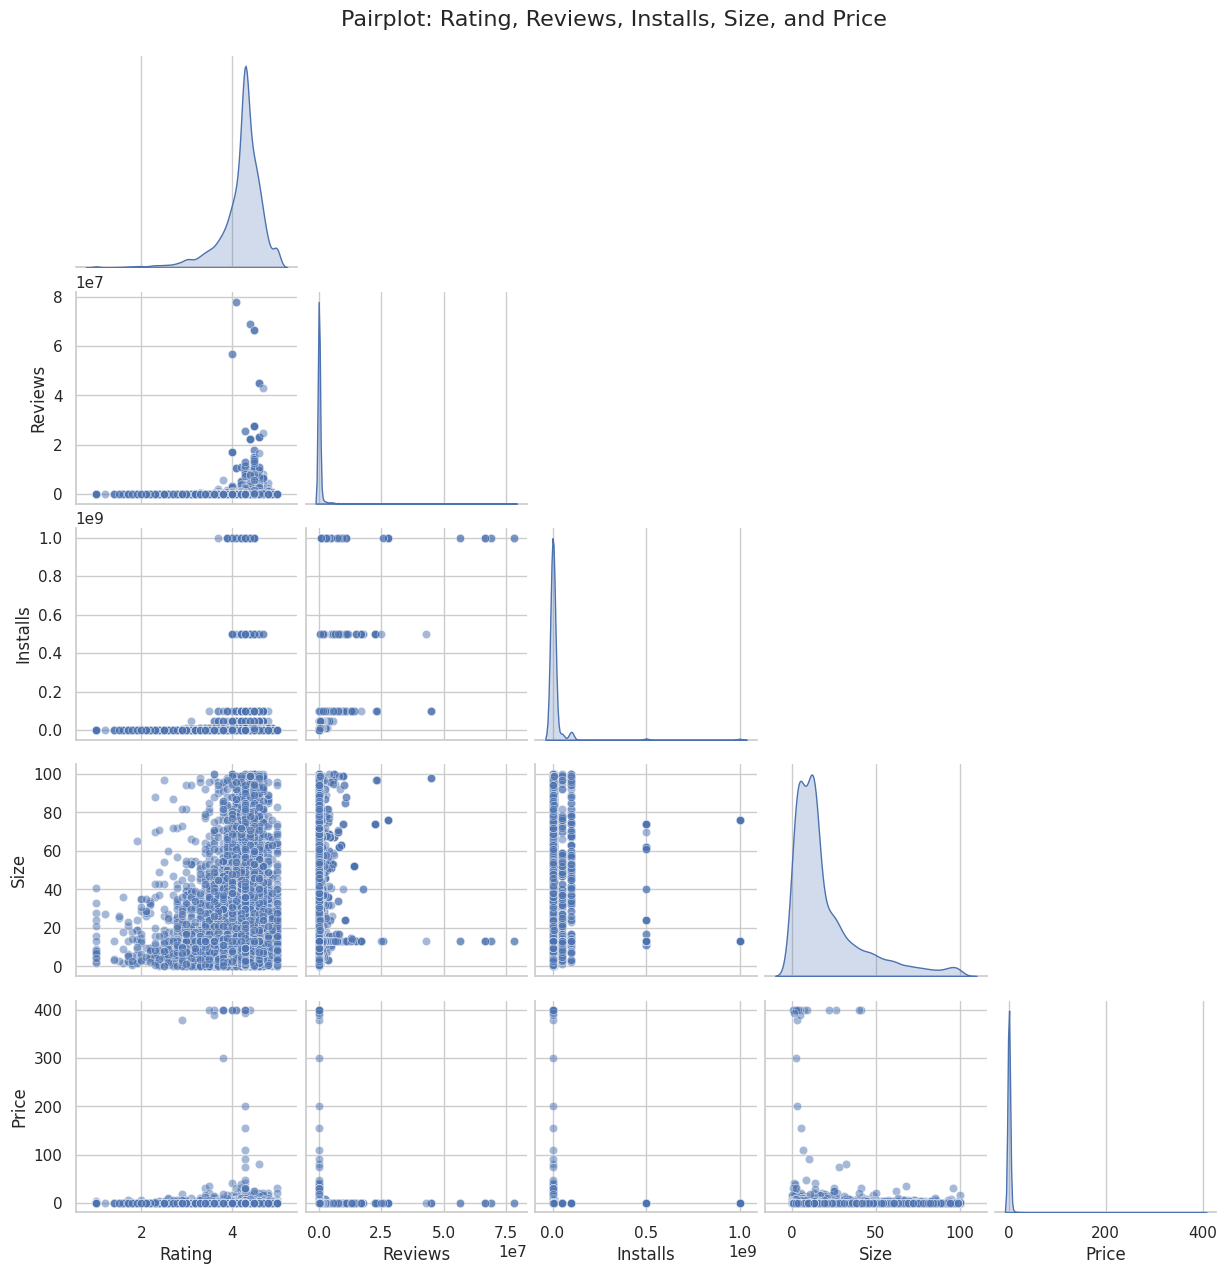

In [59]:
# Chart-15 Pairplot visualization code

#Select numeric columns
numeric_cols = ['Rating', 'Reviews', 'Installs', 'Size', 'Price']
pairplot_data = df1[numeric_cols]

#Create pairplot
sns.pairplot(pairplot_data, corner=True, diag_kind='kde', plot_kws={'alpha': 0.5})

#Add a title
plt.suptitle('Pairplot: Rating, Reviews, Installs, Size, and Price', fontsize=16, y=1.02)

#Show the plot
plt.show()


##### 1. Why did you pick the specific chart?

The pairplot is a great choice for exploring the relationships between multiple numerical features (e.g., Rating, Reviews, Installs, Size, and Price). It visually displays correlations, clusters, and distributions, providing a comprehensive overview of how these variables interact.

##### 2. What is/are the insight(s) found from the chart?

**Reviews vs. Installs:**
* A strong positive trend: Apps with higher installs tend to receive more reviews.
* The scatter plot confirms this relationship as most points form an upward cluster.

**Price vs. Installs:**
* No significant correlation: High-priced apps typically have fewer installs, suggesting affordability drives downloads.

**Size vs. Rating:**
* No clear pattern: App size does not appear to influence ratings.

**Distribution of Features:**
*  Installs and Reviews are heavily skewed, with a few apps dominating the dataset (e.g., apps with billions of installs and millions of reviews).
* Price shows many apps priced at 0, indicating a large proportion of free apps.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**
* Marketing Strategies: Focus on increasing installs to generate more reviews, as they are positively correlated. Reviews can boost credibility and attract more users.
* Pricing Strategy: Ensure apps remain competitively priced (or free) to attract higher install counts.

**No Significant Negative Growth Observed**:
However, apps with high prices may struggle to gain significant installs unless they offer unique value. Developers should carefully evaluate pricing strategies for premium apps.

#   **User Reviews Data**

## ***1. Know Your Data***

### handling duplicates

In [60]:
#Drop exact duplicates
df2.drop_duplicates(inplace=True)

#Standardize review text (lowercase)
df2['Translated_Review'] = df2['Translated_Review'].str.lower()

#Drop repeated review content per app
df2.drop_duplicates(subset=['App', 'Translated_Review', 'Sentiment'], inplace=True)

#Drop rows where both review and sentiment are missing
df2.dropna(subset=['Translated_Review', 'Sentiment'], how='all', inplace=True)

#Reset index
df2.reset_index(drop=True, inplace=True)

In [61]:
#Dataset First Look
df2

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,i like eat delicious food. that's i'm cooking ...,Positive,1.000000,0.533333
1,10 Best Foods for You,this help eating healthy exercise regular basis,Positive,0.250000,0.288462
2,10 Best Foods for You,works great especially going grocery store,Positive,0.400000,0.875000
3,10 Best Foods for You,best idea us,Positive,1.000000,0.300000
4,10 Best Foods for You,best way,Positive,1.000000,0.300000
...,...,...,...,...,...
29639,Housing-Real Estate & Property,most ads older many agents ..not much owner po...,Positive,0.173333,0.486667
29640,Housing-Real Estate & Property,"if photos posted portal load, fit purpose. i'm...",Positive,0.225000,0.447222
29641,Housing-Real Estate & Property,"dumb app, i wanted post property rent give opt...",Negative,-0.287500,0.250000
29642,Housing-Real Estate & Property,i property business got link sms happy perform...,Positive,0.800000,1.000000


In [62]:
df2.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,i like eat delicious food. that's i'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,this help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,works great especially going grocery store,Positive,0.40,0.875000
3,10 Best Foods for You,best idea us,Positive,1.00,0.300000
4,10 Best Foods for You,best way,Positive,1.00,0.300000


In [63]:
# Dataset Rows & Columns count
#shape
df2.shape

(29644, 5)

In [64]:
#Dataset Info
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29644 entries, 0 to 29643
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29644 non-null  object 
 1   Translated_Review       29639 non-null  object 
 2   Sentiment               29644 non-null  object 
 3   Sentiment_Polarity      29644 non-null  float64
 4   Sentiment_Subjectivity  29644 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.1+ MB


In [65]:
# Dataset Duplicate Value Count
df2.duplicated().sum()

np.int64(0)

In [66]:
# Missing Values/Null Values Count
df2.isnull().sum()

,0
App,0
Translated_Review,5
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


### What did you know about your dataset?

####**Dataset Overview**
This dataset contains 29,644 rows and 5 columns, with the following details:

1. **Columns and Data Types:**

* App: Contains the application names (object data type).
* Translated_Review: Contains user reviews translated into a consistent language (object data type).
* Sentiment: Represents the sentiment of the reviews (e.g., Positive, Negative, Neutral) (float64 data type).
* Sentiment_Polarity: Indicates the polarity of the sentiment, measuring how positive or negative it is (float64 data type).
* Sentiment_Subjectivity: Reflects the subjectivity of the sentiment, showing the degree to which it is opinion-based (float64 data type).

2. **Duplicate Records:**

* Duplicate values have already been removed, ensuring data uniqueness.

3. **Missing Values:**

* The Translated_Review column has 5 missing values that may need handling to ensure the completeness of the dataset.

## ***2. Understanding Your Variables***

In [67]:
# Dataset Columns
df2.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

In [68]:
# Dataset Describe
df2.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,29644.000000,29644.000000
mean,0.188077,0.490582
std,0.355446,0.266001
min,-1.000000,0.000000
25%,0.000000,0.350000
50%,0.155744,0.513648
75%,0.420000,0.652411
max,1.000000,1.000000


### Variables Description

1. **`App`**: The name of the application (e.g., Instagram, Facebook), used to uniquely identify each app.
2. **`Translated_Review`**: The text of user reviews, standardized and cleaned for analysis.
3. **`Sentiment`**: The sentiment expressed in the user review, categorized as **Positive**, **Neutral**, or **Negative**.
4. **`Sentiment_Polarity`**: A numeric value ranging from -1 (most negative) to +1 (most positive), quantifying the sentiment of a review.
5. **`Sentiment_Subjectivity`**: A numeric value ranging from 0 (completely objective) to 1 (completely subjective), indicating the degree of personal opinion in a review.

### Check Unique Values for each variable.

In [69]:
df2.nunique()

,0
App,865
Translated_Review,27888
Sentiment,3
Sentiment_Polarity,5410
Sentiment_Subjectivity,4474


In [70]:
#unique values for Sentiment column
df2['Sentiment'].unique()

array(['Positive', 'Neutral', 'Negative'], dtype=object)

## 3. ***Data Wrangling***

### Data Wrangling Code

### handling missing values

In [71]:
# check data type of each column in datframe df2
df2.dtypes

,0
App,object
Translated_Review,object
Sentiment,object
Sentiment_Polarity,float64
Sentiment_Subjectivity,float64


In [72]:
#num cols
#print all numerical columns
num_cols=df2.select_dtypes(include=['int64','float64'])
num_cols

,Sentiment_Polarity,Sentiment_Subjectivity
0,1.000000,0.533333
1,0.250000,0.288462
2,0.400000,0.875000
3,1.000000,0.300000
4,1.000000,0.300000
...,...,...
29639,0.173333,0.486667
29640,0.225000,0.447222
29641,-0.287500,0.250000
29642,0.800000,1.000000


In [73]:
# cat cols
# print all categorical columns
cat_cols=df2.select_dtypes(include=['object'])
cat_cols

,App,Translated_Review,Sentiment
0,10 Best Foods for You,i like eat delicious food. that's i'm cooking ...,Positive
1,10 Best Foods for You,this help eating healthy exercise regular basis,Positive
2,10 Best Foods for You,works great especially going grocery store,Positive
3,10 Best Foods for You,best idea us,Positive
4,10 Best Foods for You,best way,Positive
...,...,...,...
29639,Housing-Real Estate & Property,most ads older many agents ..not much owner po...,Positive
29640,Housing-Real Estate & Property,"if photos posted portal load, fit purpose. i'm...",Positive
29641,Housing-Real Estate & Property,"dumb app, i wanted post property rent give opt...",Negative
29642,Housing-Real Estate & Property,i property business got link sms happy perform...,Positive


In [74]:
# Missing Values/Null Values Count
df2.isnull().sum()

,0
App,0
Translated_Review,5
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [75]:
df2.dropna(subset=['Translated_Review'], inplace=True)

In [76]:
#Final check: ensure no missing values remain
print("Remaining Missing Values:")
print(df2.isnull().sum())

Remaining Missing Values:
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64


### What all manipulations have you done and insights you found?

####**Data Manipulations**
In the dataset comprising app reviews and sentiment analysis data, the following preprocessing steps were performed:

1. **Column Categorization:**

* The dataset contains 29,644 rows and 5 columns.
* Columns were classified as:
  * Categorical Columns: App, Translated_Review, Sentiment (data type: object).
  * Numerical Columns: Sentiment_Polarity, Sentiment_Subjectivity (data type: float64).

2. **Handling Missing Values:**

* There were 5 missing values in the Translated_Review column.
* Rows containing missing values in this column were removed using the dropna() function to ensure data consistency.

####**Insights Gained**
* The dataset has been cleaned, with all null values addressed and duplicate entries already handled.
* Categorical Features (App, Translated_Review, Sentiment) can provide insights into app performance and user sentiment.
* Numerical Features (Sentiment_Polarity, Sentiment_Subjectivity) allow for sentiment analysis:
  * Polarity: Measures the positivity or negativity of user reviews.
  * Subjectivity: Indicates whether reviews are factual or opinion-based.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

## **Univariate**

16. **What is the distribution of sentiments (Positive, Neutral, Negative) in the dataset?**


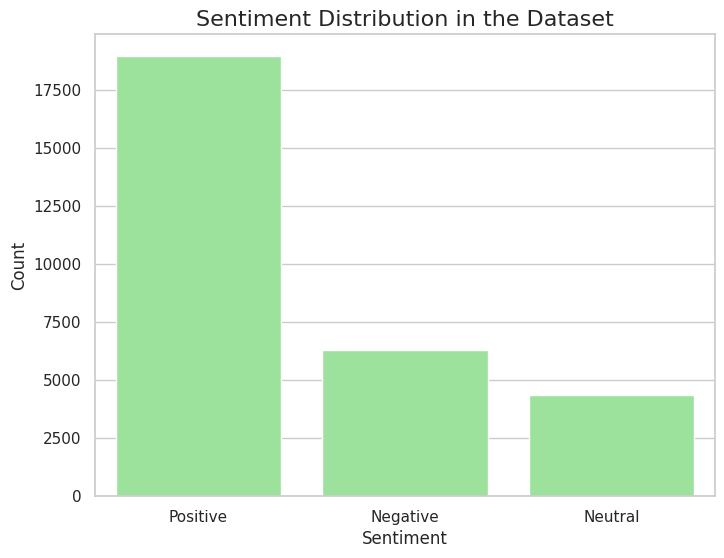

In [77]:
# Chart - 16 visualization code
#Bar Chart

#Count the occurrences of each sentiment
sentiment_counts = df2['Sentiment'].value_counts()

#Plot the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, color='lightgreen') #create bar chart

#Add titles and labels
plt.title('Sentiment Distribution in the Dataset', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

#Show the plot
plt.show()


##### 1. Why did you pick the specific chart?

I selected a bar chart because it effectively displays the frequency of categorical data—in this case, sentiment labels (Positive, Negative, Neutral). It offers a clear visual comparison of how user sentiments are distributed across the dataset.



##### 2. What is/are the insight(s) found from the chart?

The majority of user reviews are positive, followed by negative and then neutral sentiments. This indicates that users generally have favorable experiences with the apps.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

* Yes, the insights indicate a healthy user perception, which can reinforce brand trust and user retention.
* Negative Insight: The significant portion of negative reviews highlights areas for improvement. Addressing issues raised in these reviews could prevent churn and support long-term growth.



17. **What is the distribution of sentiment polarity scores?**

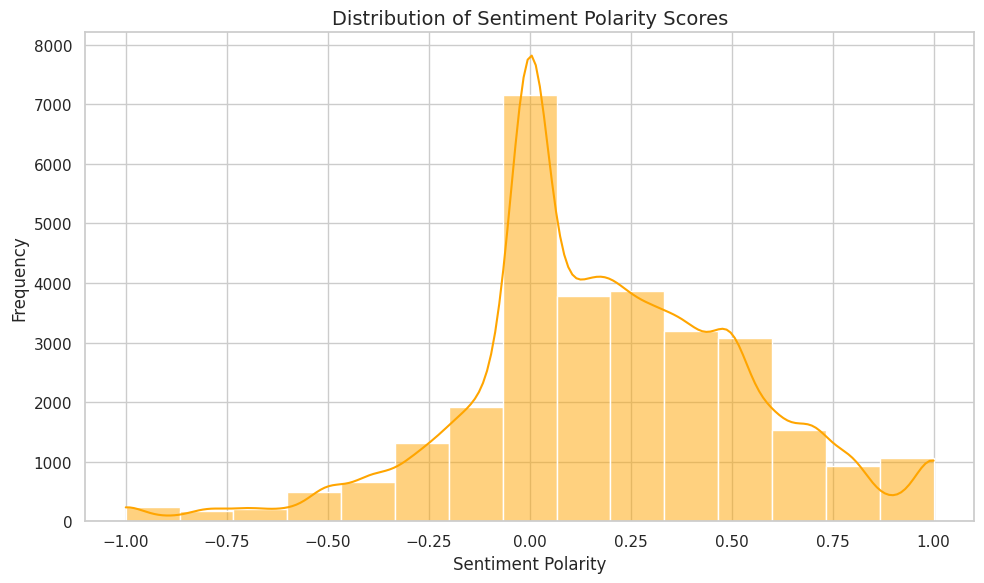

In [78]:
# Chart - 17 visualization code
#Chart: Histogram or KDE plot.

# Set the plot size and style
plt.figure(figsize=(10,6))
sns.histplot(data=df2, x='Sentiment_Polarity',bins=15,kde=True, color='orange') #create histogram

#Add title and labels
plt.title('Distribution of Sentiment Polarity Scores',fontsize=14)
plt.xlabel('Sentiment Polarity',fontsize=12)
plt.ylabel('Frequency', fontsize=12)

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a histogram with a KDE curve to visualize the distribution of sentiment polarity scores. This chart effectively reveals how user sentiments are spread across the scale from negative to positive and shows the density of scores across the entire range.



##### 2. What is/are the insight(s) found from the chart?

The chart shows that most sentiment polarity scores are centered around 0, indicating neutral sentiment. There is also a noticeable rightward skew, suggesting that users are more likely to leave slightly positive reviews rather than strongly negative ones.



##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

* Yes, these insights are valuable. Understanding that most user feedback is neutral to slightly positive can guide app developers to focus on improving specific areas to push user sentiment toward stronger positivity.
* Negative Growth Insight: If developers ignore this trend and fail to act on user feedback that hovers around neutrality, it may lead to dissatisfaction over time and potentially harm app reputation.



18. **What is the distribution of sentiment subjectivity scores?**

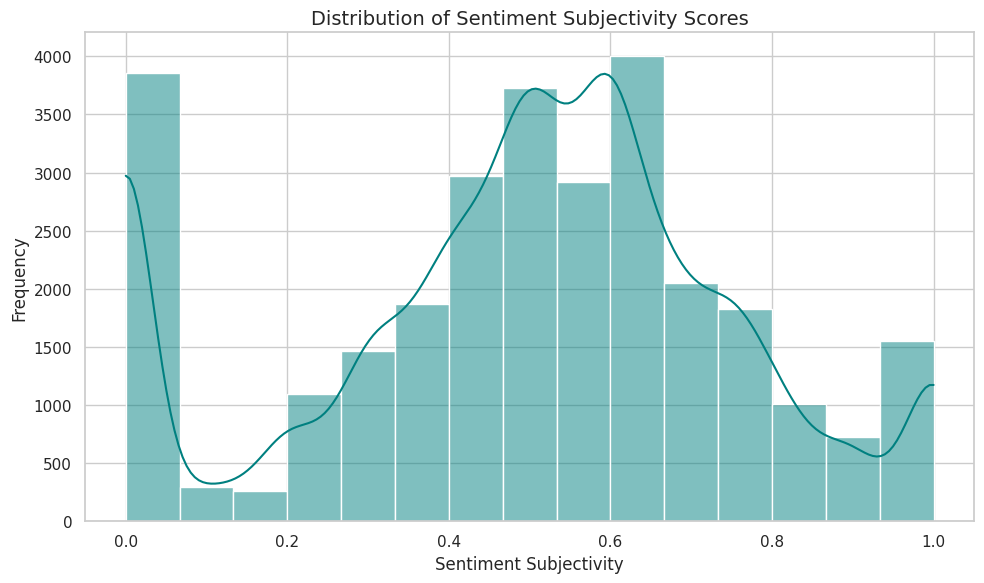

In [79]:
# Chart - 18 visualization code
#Chart: Histogram or KDE plot.

# Set the plot size and style
plt.figure(figsize=(10,6))
sns.histplot(data=df2, x='Sentiment_Subjectivity',bins=15,kde=True, color='teal') #create histogram

#Add title and labels
plt.title('Distribution of Sentiment Subjectivity Scores',fontsize=14)
plt.xlabel('Sentiment Subjectivity',fontsize=12)
plt.ylabel('Frequency', fontsize=12)

#Show the plot
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE curve is ideal for visualizing the distribution of a continuous variable like Sentiment Subjectivity, which ranges from 0 to 1. It helps understand whether user reviews are more factual (objective) or opinion-based (subjective).



##### 2. What is/are the insight(s) found from the chart?

* The subjectivity scores are spread across the range, with peaks near 0.0 and around 0.5–0.6, indicating a mix of objective and semi-subjective reviews.
* Very few reviews have extremely high subjectivity (near 1.0), suggesting that most feedback includes some factual information.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes. Knowing that users often share semi-subjective or factual reviews helps businesses:
* Prioritize features or improvements based on constructive feedback.
* Detect genuine feedback vs. overly emotional or vague responses.

(ii) A very high number of extremely subjective reviews could signal emotional bias, which may reduce the reliability of user feedback. However, in this case, such reviews are limited.

## **Bivariate**

19. **Is there a relationship between sentiment polarity and subjectivity?**

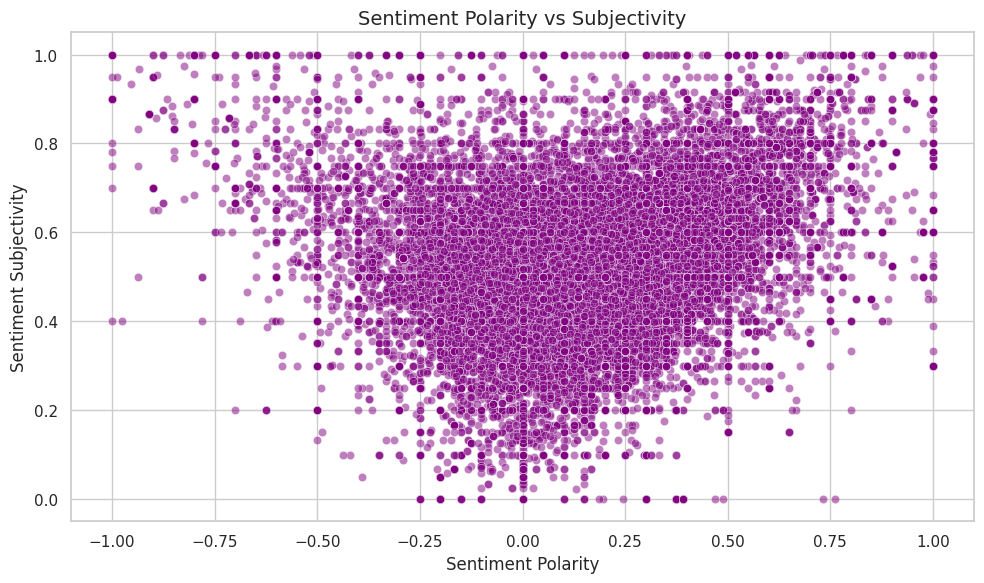

In [80]:
# Chart - 19 visualization code
#Chart: Scatter plot

# Set the plot size and style
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df2, x='Sentiment_Polarity', y='Sentiment_Subjectivity', alpha=0.5, color='purple') #create scatterplot

#Add title and labels
plt.title('Sentiment Polarity vs Subjectivity', fontsize=14)
plt.xlabel('Sentiment Polarity', fontsize=12)
plt.ylabel('Sentiment Subjectivity', fontsize=12)

#Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

I chose a scatter plot because it is ideal for visualizing the relationship between two continuous numeric variables—in this case, Sentiment Polarity and Sentiment Subjectivity. It allows us to observe clustering patterns, potential correlations, or spread across the ranges.

2. What is/are the insight(s) found from the chart?

* There is no strong linear relationship between sentiment polarity and subjectivity.
* Most data points are clustered around neutral polarity (0) and moderate subjectivity (0.4 to 0.6).
* Extreme values of polarity (close to -1 or 1) are less frequent and tend to have a wide range of subjectivity.

3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: Understanding that most user reviews are moderately subjective and emotionally balanced can guide businesses in crafting more relatable and emotionally resonant content.
* No Negative Impact Identified: However, the lack of a strong correlation implies that improving subjectivity in communication may not directly increase positive polarity. So, efforts should be focused on overall user satisfaction rather than tone manipulation alone.



20. **What are the top 10 apps with highest average sentiment polarity?**

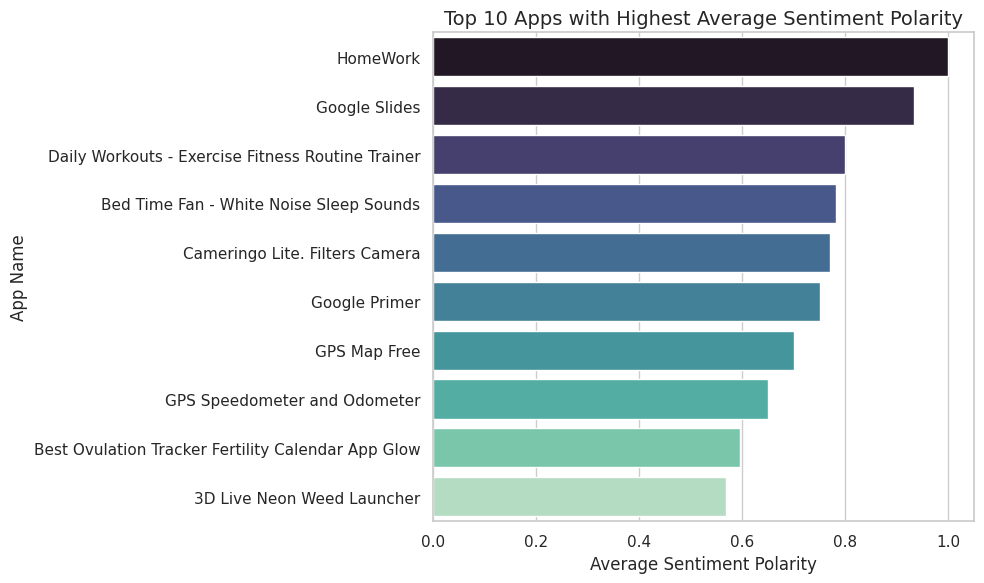

In [81]:
# Chart - 20 visualization code
#Bar Chart

#Group by 'App' and calculate the average sentiment polarity
top_sentiment_apps = df2.groupby('App')['Sentiment_Polarity'].mean().sort_values(ascending=False).head(10)

# Set the plot size and style
plt.figure(figsize=(10, 6))
sns.barplot(x=top_sentiment_apps.values, y=top_sentiment_apps.index, hue=top_sentiment_apps.index, palette='mako',legend=False) #create bar chart

#Add labels and title
plt.xlabel('Average Sentiment Polarity', fontsize=12)
plt.ylabel('App Name', fontsize=12)
plt.title('Top 10 Apps with Highest Average Sentiment Polarity', fontsize=14)

#Show the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected for its clarity in comparing average sentiment polarity across apps and its ability to display long app names effectively.

2. What is/are the insight(s) found from the chart?


The chart shows that "Bed Time Fan - White Noise Sleep Sounds" has the highest average sentiment polarity. All top 10 apps have strong positive user sentiment, indicating high user satisfaction across various categories.

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can drive positive impact by identifying top-performing apps for promotion or benchmarking. There are no direct signs of negative growth, but consistently low-performing categories (not shown) could indicate areas needing improvement.

## **Multivariate**

21. **How do sentiment polarity, subjectivity, and review count correlate across apps?**

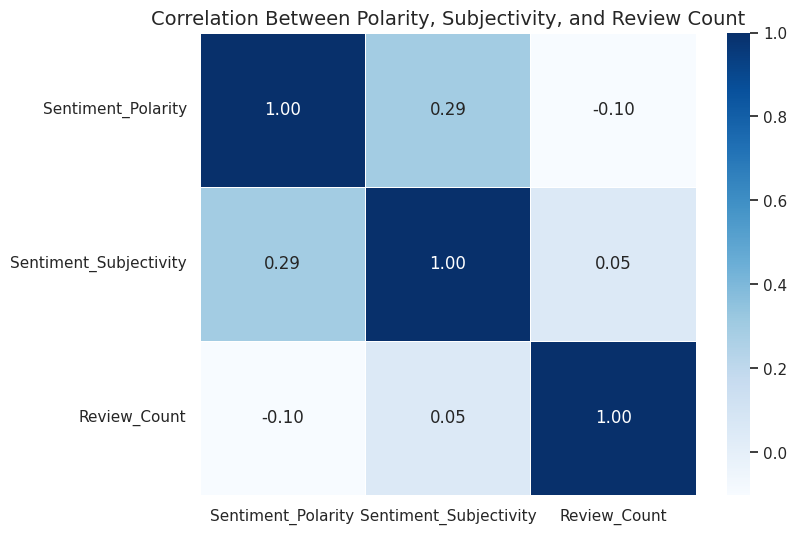

In [82]:
# Chart - 21 visualization code
#Heatmap

# Group data by 'App' and calculate mean polarity, mean subjectivity, and review count
app_sentiment_summary = df2.groupby('App').agg({
    'Sentiment_Polarity': 'mean',
    'Sentiment_Subjectivity': 'mean',
    'Translated_Review': 'count'  # Count of reviews per app
}).rename(columns={'Translated_Review': 'Review_Count'})

# Compute correlation matrix
correlation_matrix = app_sentiment_summary.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Polarity, Subjectivity, and Review Count', fontsize=14) #add title
plt.show() #show the plot


##### 1. Why did you pick the specific chart?

A heatmap effectively visualizes correlations between numerical variables. It clearly shows relationships between sentiment polarity, subjectivity, and review count across apps in a compact, interpretable format.



2. What is/are the insight(s) found from the chart?


* Polarity and Subjectivity show a moderate positive correlation (0.29).
* Polarity and Review Count show a weak negative correlation (-0.10).
* Subjectivity and Review Count have negligible correlation (0.05).



3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes, the insights can support positive business impact. The moderate positive correlation between subjectivity and polarity suggests that encouraging users to write more detailed and expressive reviews may lead to more positive sentiment, enhancing app reputation.

(ii)However, the weak negative correlation between review count and polarity may indicate a risk of declining sentiment as an app gains popularity. This could result from increased visibility attracting more critical feedback. Businesses should proactively manage user experience and feedback channels to mitigate this risk.

22. **How are sentiment polarity and subjectivity related across different sentiment types?**

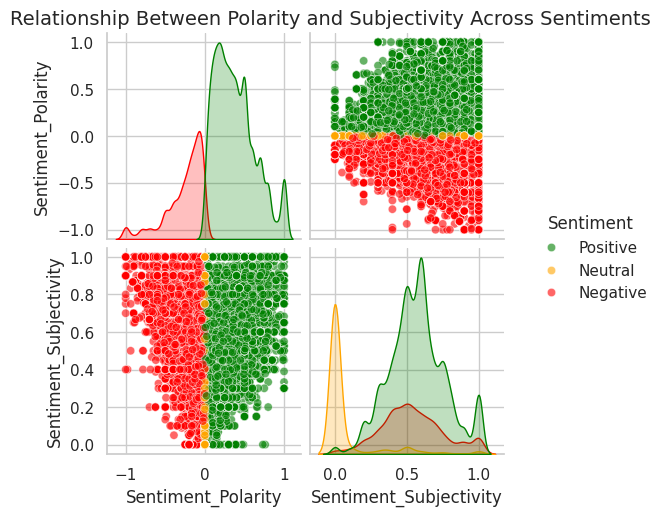

In [83]:
# Chart - 22 visualization code
#Pairplot

# Create a pairplot for polarity and subjectivity, grouped by sentiment
sns.pairplot(df2, vars=['Sentiment_Polarity', 'Sentiment_Subjectivity'], hue='Sentiment',
             palette={'Positive': 'green', 'Neutral': 'orange', 'Negative': 'red'},
             diag_kind='kde', plot_kws={'alpha': 0.6})

# Add a title
plt.suptitle('Relationship Between Polarity and Subjectivity Across Sentiments', y=1.02, fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

The pairplot is an excellent choice to explore relationships between numerical variables (Sentiment_Polarity and Sentiment_Subjectivity), categorized by sentiment types (Positive, Neutral, Negative). It highlights trends, overlaps, and clusters while providing individual distributions for both variables.

2. What is/are the insight(s) found from the chart?



**Positive Sentiments (Green):**
* Strongly concentrated in the upper-right quadrant, indicating high polarity (positive tone) and varying levels of subjectivity.
* Positive reviews tend to have a wider range of subjectivity compared to others.

**Neutral Sentiments (Orange):**
* Clustered around 0 polarity, as expected.
* Subjectivity for neutral reviews is concentrated around mid-range (0.4 to 0.6).

**Negative Sentiments (Red):**
* Concentrated in the lower-left quadrant, showing negative polarity and a broader subjectivity range.
* Many negative reviews are closer to 0 subjectivity, suggesting they may be more objective.

**Overlap Between Sentiments:**
* Some overlap is observed near 0 polarity, where positive, neutral, and negative sentiments mix, indicating ambiguity in tone.



3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

(i) Yes, the insights can drive positive business impact by:
1. Improving Sentiment Analysis: Fine-tuning models for better classification of reviews.
2. Prioritizing Feedback: Addressing highly subjective negative reviews to enhance user satisfaction and leveraging positive feedback for engagement strategies.
3. Refining Neutral Sentiments: Identifying mid-subjectivity neutral reviews to pinpoint areas for improvement.

(ii) No significant risks were identified. However:
* Polarity Overlap: Misclassification of reviews near 0 polarity could lead to incorrect decisions.
* Subjective Negative Reviews: Ignoring these may harm user retention and brand reputation.


## **Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?Explain Briefly.

To achieve business objectives, I recommend the following:

1. **Enhance App Quality:**

* Address issues in apps with ratings below 4.0 by analyzing user feedback and implementing improvements in design, performance, or features.

2. **Target High-Demand Categories:**

* Focus on "COMMUNICATION," "GAME," and "FAMILY" categories for user acquisition while innovating in niche areas with less competition.

3. **Optimize User Engagement:**

* Encourage reviews by prompting satisfied users and addressing negative reviews promptly. Leverage insights from polarity and subjectivity scores to refine app descriptions and updates.

4. **Adopt a Freemium Model:**

* Since 92% of apps are free, a freemium model (free app with in-app purchases) can balance user demand and revenue generation.

5. **Monitor and Update Regularly:**

* Maintain competitive relevance by frequently updating apps, as consistent updates correlate with higher user retention.

# **Conclusion**

This analysis of Play Store app data and user reviews successfully uncovers the key drivers of app success and provides actionable insights for developers in a competitive market. The findings emphasize the importance of maintaining high ratings, optimizing app features and size, and addressing user feedback. Additionally, prioritizing data-driven decision-making, strategically selecting app categories, and implementing effective monetization strategies can enhance app visibility, attract a larger user base, and achieve sustainable growth. By focusing on app quality, user engagement, and market awareness, developers can ensure long-term success within the Play Store ecosystem.

